In [134]:
# import neccessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
# get dataset
X = pd.read_csv("../data/raw/X.csv")
y = pd.read_csv("../data/raw/y.csv")

In [136]:
X.sample(3)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
37166,37,management,single,tertiary,no,584,yes,no,telephone,13,may,115,1,-1,0,NaN
17433,43,blue-collar,single,primary,yes,69,no,yes,cellular,28,jul,267,5,-1,0,NaN
17989,44,services,married,secondary,no,2439,yes,no,cellular,30,jul,133,2,-1,0,NaN


In [137]:
X_clean = X.copy()

## HANDLE MISSING VALUES

In [138]:
# BIG POV OF missing values

# true NaNs: 
# job -> 288 -> make unkown tag for the job [fillna("unkown")]
# education -> 1857 -> fill with most frequent
# contact -> 13020 -> fill unknown
# poutcome -> 36959 -> fill unknown

X.isna().sum().reset_index().T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
index,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,0,288,0,1857,0,0,0,0,13020,0,0,0,0,0,0,36959


In [139]:
# Action on missing values
X_clean["job"] = X["job"].fillna("unknown")
X_clean["education"] = X["education"].fillna(X["education"].mode()[0])
X_clean["contact"] = X["contact"].fillna("unknown")
X_clean["poutcome"] = X["poutcome"].fillna("unknown")

## see distribution

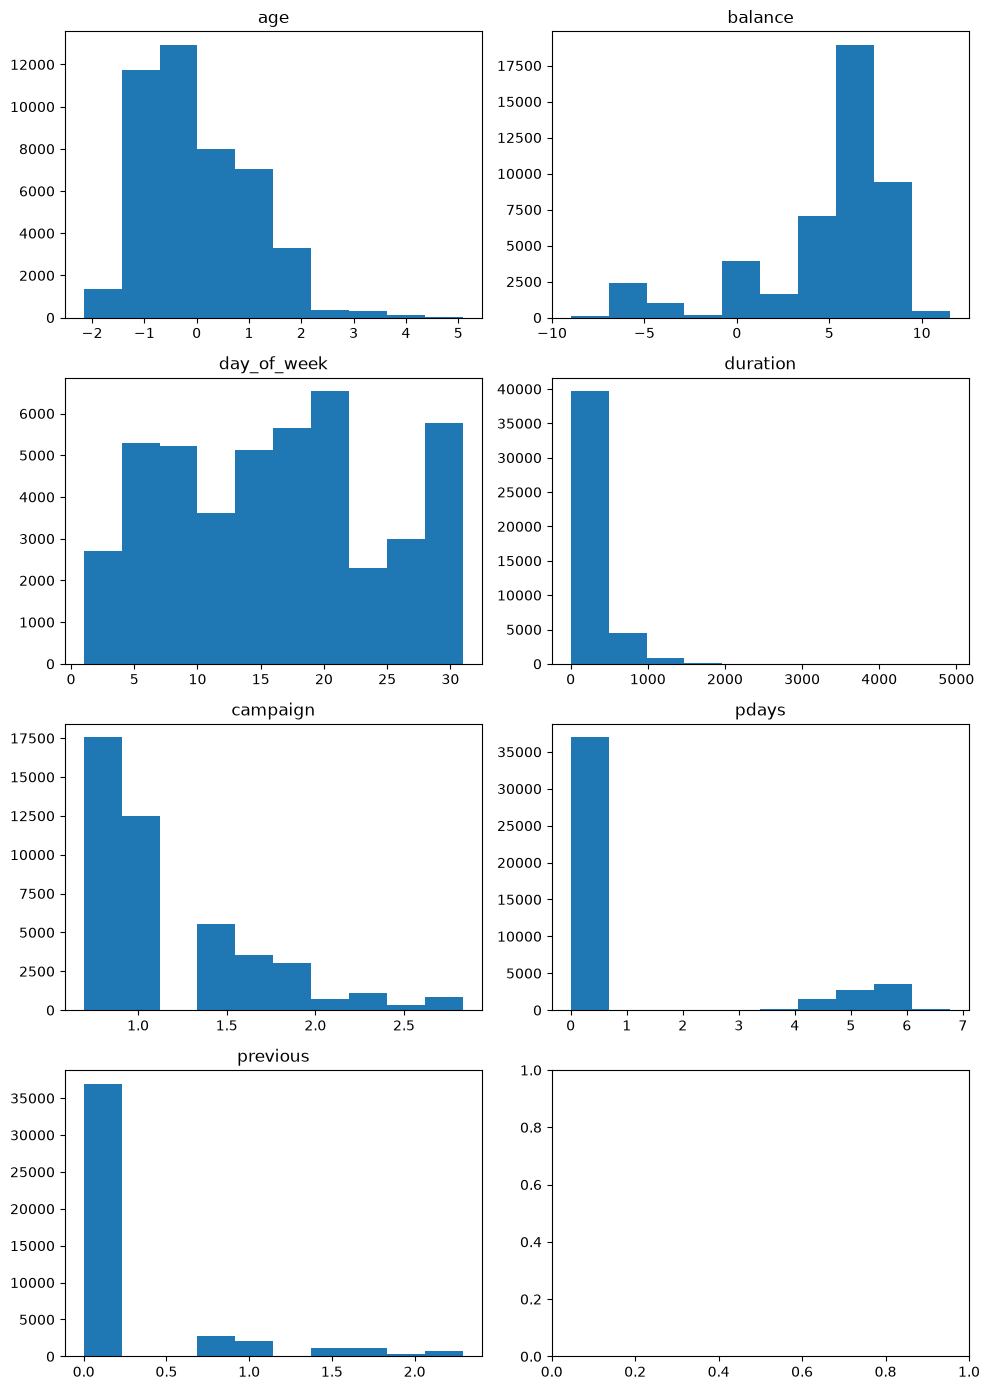

In [165]:
num_cols = X.select_dtypes(include=["number"]).columns

ncols = 2
nrows = int(np.ceil(len(num_cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))

axes_flat = [ax for axs in axes for ax in axs]
for ax, col in zip(axes_flat, num_cols):
    ax.hist(X_clean[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
# Highly right skewed -> balance, campaign, pdays, previous -> log transformation
# Right Skewed -> age -> Standardization
# multinomial -> day_of_week -> no need

# duration is not good for model can cause to overfit

In [129]:
def z_scale(X):
    return (X - X.mean())/X.std()

In [ ]:
X_clean["campaign"] = np.log1p(X["campaign"].clip(upper=X["campaign"].quantile(.99)))
X_clean["previous"] = np.log1p(X["previous"].clip(upper=X["previous"].quantile(.99)))
X_clean["pdays"] = np.log1p(X["pdays"]).clip(lower=0)
X_clean["balance"] = np.sign(X["balance"]) * np.log1p(np.abs(X["balance"])) 
X_clean["age"] = z_scale(X["age"])

/home/lochan/projects/bank-marketing/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


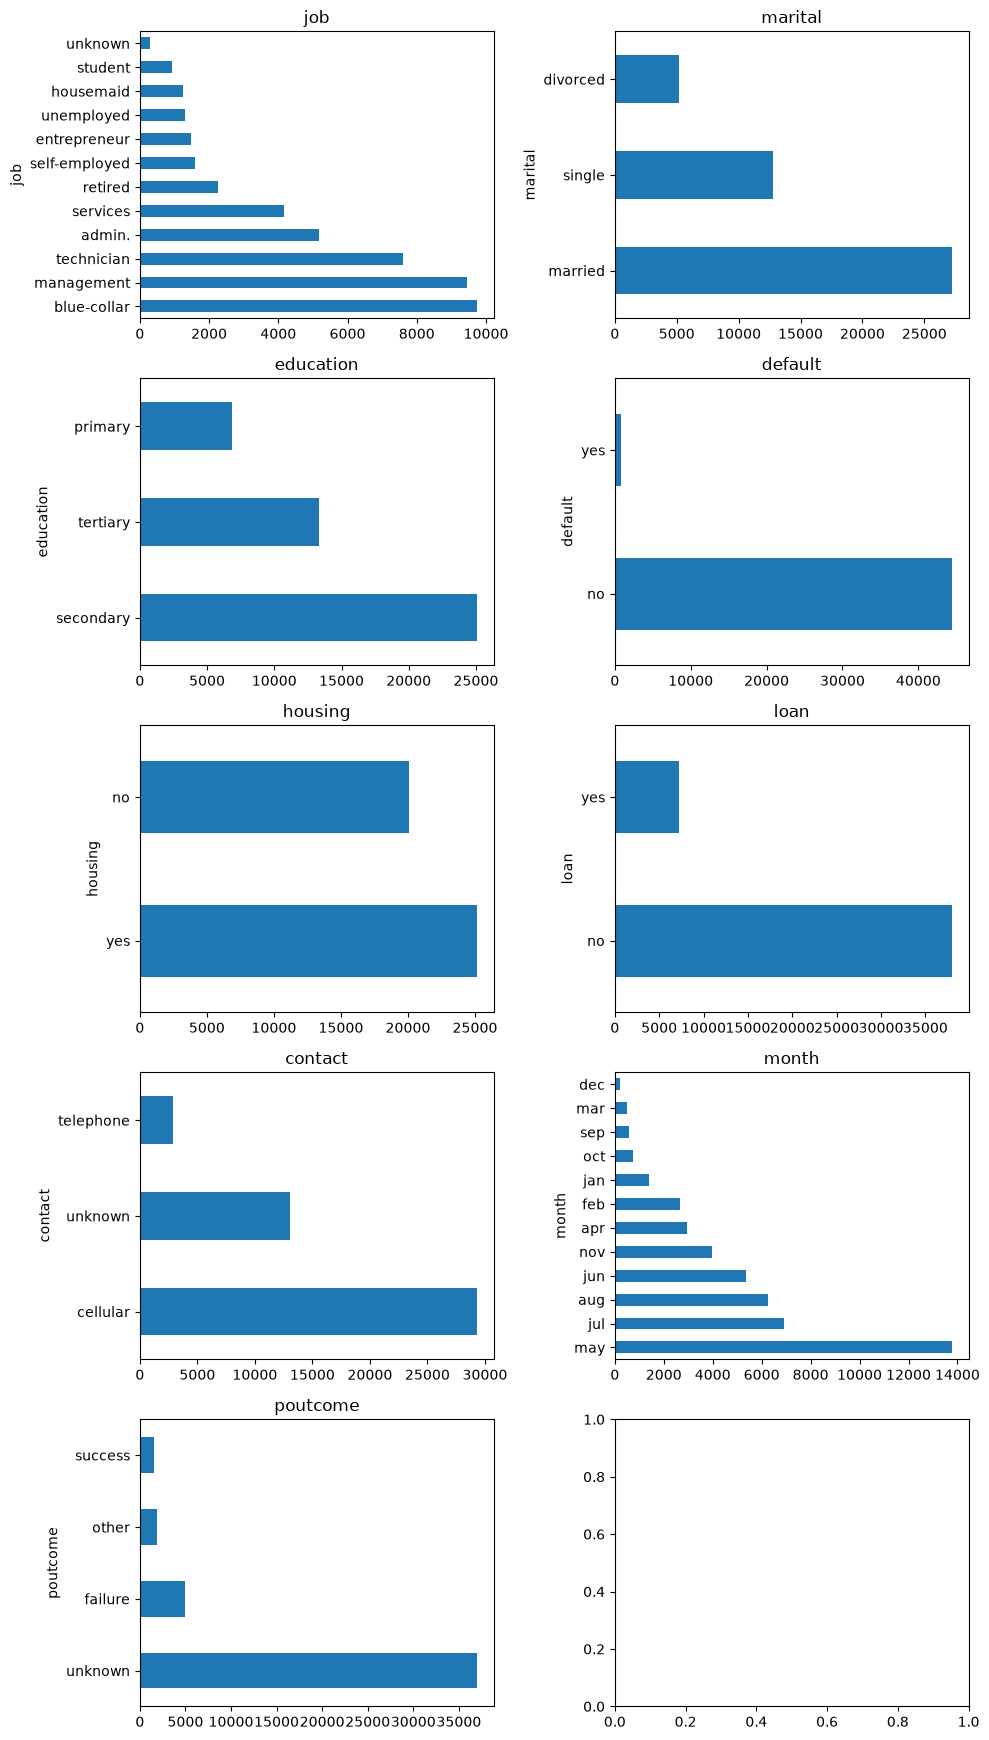

In [175]:
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns


ncols = 2
nrows = int(np.ceil(len(cat_cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))

axes_flat = [ax for axs in axes for ax in axs]
for ax, col in zip(axes_flat, cat_cols):
    X_clean[col].value_counts().plot.barh(ax=ax, title=col)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# binary classes -> default, housing, loan -> binary mapping
# Less classes -> marital, education, default, housing, loan, contact, poutcome -> One Hot
# some classes -> job, month -> One Hot

In [187]:
X_clean["default"] = (X_clean["default"] == "yes").astype(int)
X_clean["housing"] = (X_clean["housing"] == "yes").astype(int)
X_clean["loan"] = (X_clean["loan"] == "yes").astype(int)
X_clean = pd.get_dummies(X_clean, columns=["marital", "education", "default", "housing", "loan", "contact", "poutcome", "job", "month"], dtype=int)

In [197]:
X_clean = X_clean.drop(columns=["duration", "day_of_week"])

In [192]:
y_clean = (y == "yes").astype(int)

In [193]:
y_clean

,y
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0
